<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
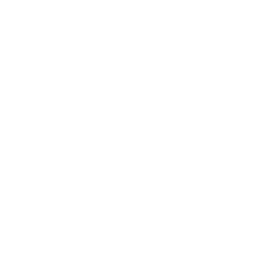
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Modelo Logit de Respuesta al Tratamiento</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacéutica / Análisis de Eficacia Clínica &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Este cuaderno ajusta un **modelo logit por máxima verosimilitud** para un criterio de valoración binario de respuesta al tratamiento de Fase III (respondedor frente a no respondedor) usando **PROC CATMOD**. Los dos factores explicativos son ambos categóricos: el `treatment_arm` aleatorizado (DRUG_HIGH, DRUG_LOW, PLACEBO) y un estrato `severity_grp` de tres niveles derivado al agrupar la severidad basal de la enfermedad (Mild / Moderate / Severe). CATMOD clasifica cruzadamente los datos en una pequeña tabla de contingencia de poblaciones y ajusta el logit de respuesta por mínimos cuadrados ponderados / máxima verosimilitud, que es el diseño para el que CATMOD está construido.

El modelo produce una tabla de Análisis de Varianza por Máxima Verosimilitud que prueba si cada factor contribuye al logit de respuesta, y una tabla de estimaciones de parámetros que se captura con `ODS OUTPUT` y se exporta para un forest plot posterior. Todas las cifras citadas en la sección de Interpretación de abajo se leen directamente de la salida ejecutada.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Datos sintéticos de respuesta de Fase III: brazo de tratamiento, severidad basal, estrato de severidad y respuesta binaria | 5,000 |

---

In [1]:
/* --------------------------------------------------------
   Generar datos sintéticos de respuesta al tratamiento
   de un ensayo de Fase III.
   Resultado binario: respondedor (1) vs no respondedor (0).
   La gravedad basal en escala 0-100 se agrupa en un
   estrato ordinal para que el análisis sea una tabla de
   contingencia categórica limpia: el diseño para el que
   PROC CATMOD está pensado.
   -------------------------------------------------------- */
DATOS work.trial_resp;
    LLAMAR streaminit(42);
    ARREGLO arm_list[3] $12 _temporary_ ('FARMACO_ALTA' 'FARMACO_BAJA' 'PLACEBO');
    HACER patient_id = 1 HASTA 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        SI baseline_severity < 0 ENTONCES baseline_severity = 0;
        SI baseline_severity > 100 ENTONCES baseline_severity = 100;
        /* Estrato ordinal de gravedad basal */
        LONGITUD severity_grp $10;
        SI baseline_severity < 45 ENTONCES severity_grp = 'Leve';
        SINO SI baseline_severity < 65 ENTONCES severity_grp = 'Moderada';
        SINO severity_grp = 'Grave';
        AGE = int(rand('normal', 58, 11));
        SI AGE < 18 ENTONCES AGE = 18;
        SI AGE > 85 ENTONCES AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');
        /* La probabilidad real de respuesta sube con la dosis y la gravedad */
        SI treatment_arm = 'FARMACO_ALTA' ENTONCES logit_p = -0.8 + 0.015 * baseline_severity;
        SINO SI treatment_arm = 'FARMACO_BAJA' ENTONCES logit_p = -1.2 + 0.012 * baseline_severity;
        SINO logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        RESPONSE = (rand('uniform') < prob_resp);
        SALIDA;
    END;
    ELIMINAR arm_idx logit_p prob_resp;
EJECUTAR;


NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.36 seconds
  cpu   1.36 seconds


---

                                 Recuentos de respuesta por grupo y estrato de gravedad                                 

                                                   The FREQ Procedure

Table of Grupo de tratamiento by Respuesta

Grupo de tratamiento |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
FARMACO_ALTA         |        11 |        18 |         29
---------------------+-----------+-----------+-----------
FARMACO_BAJA         |        21 |        12 |         33
---------------------+-----------+-----------+-----------
PLACEBO              |        28 |        10 |         38
---------------------+-----------+-----------+-----------
Total                |        60 |        40 |        100


Controlling for Grupo de tratamiento=FARMACO_ALTA

Table of Estrato de gravedad basal by Respuesta

Estrato de gravedad basal |         0 |         1 |      Total
--------------------------+-----------+-----------+-----------
Grave        


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


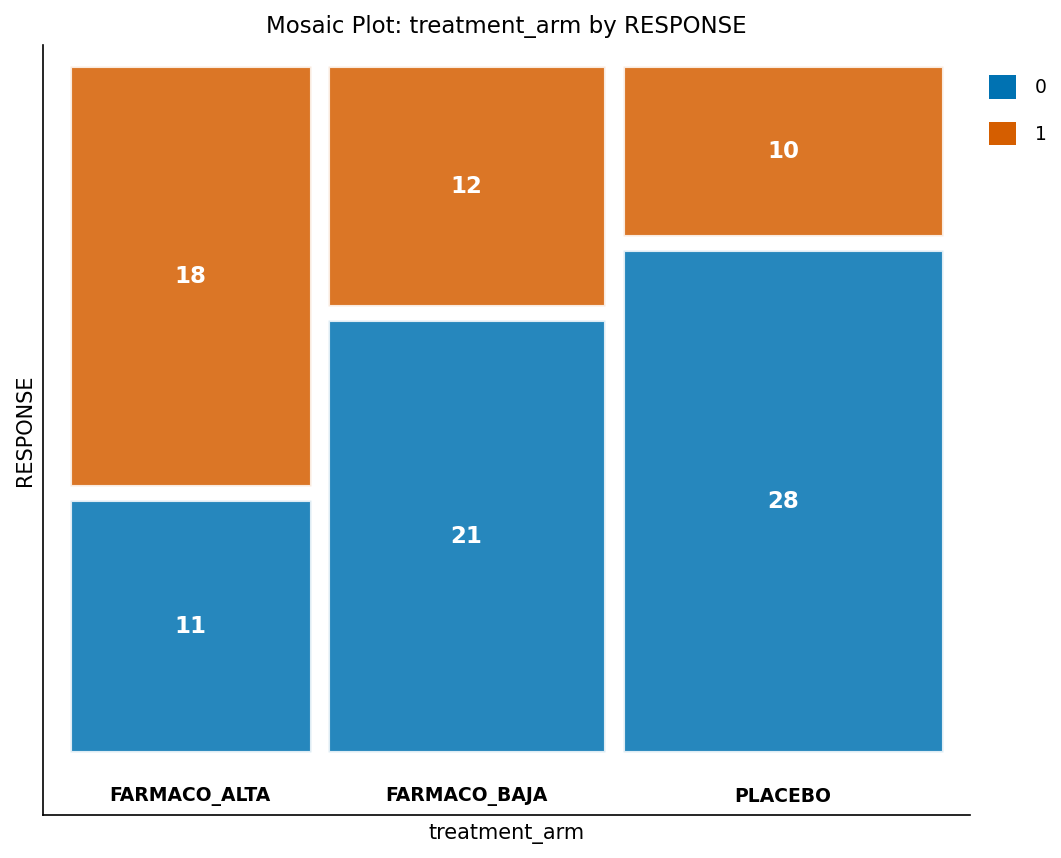

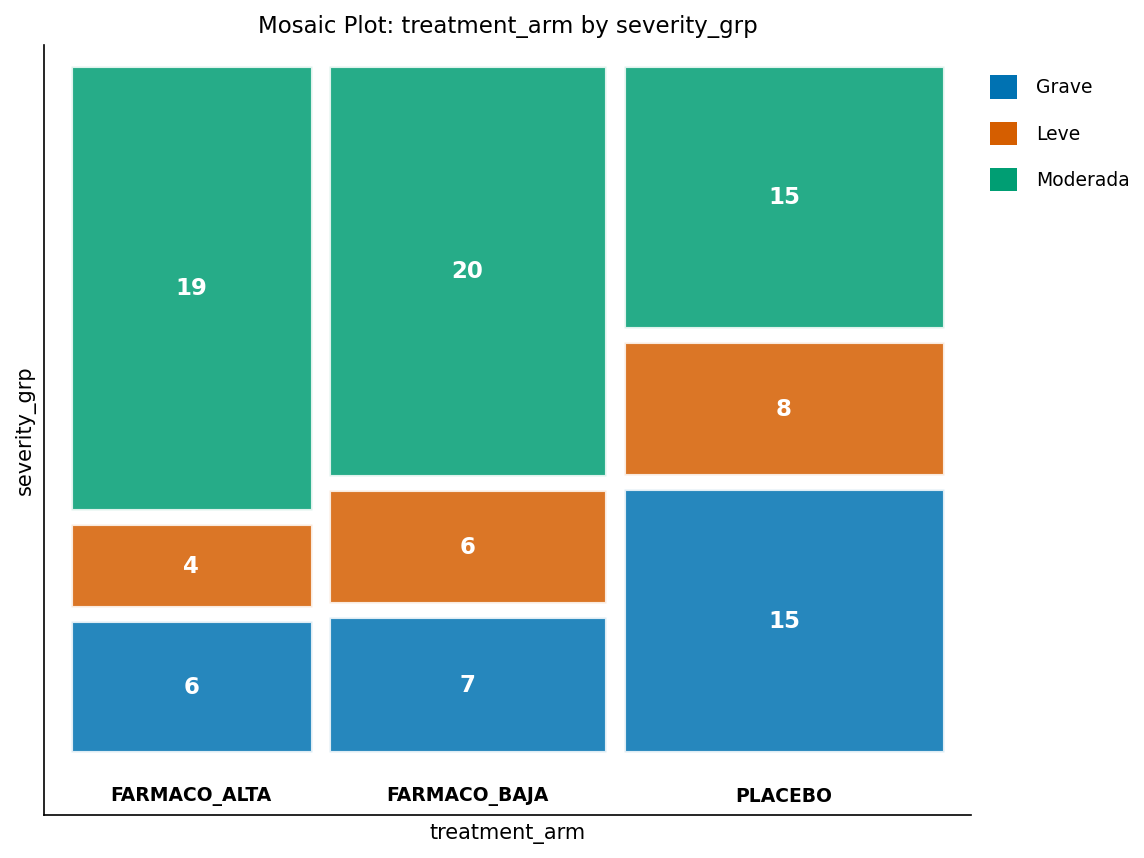

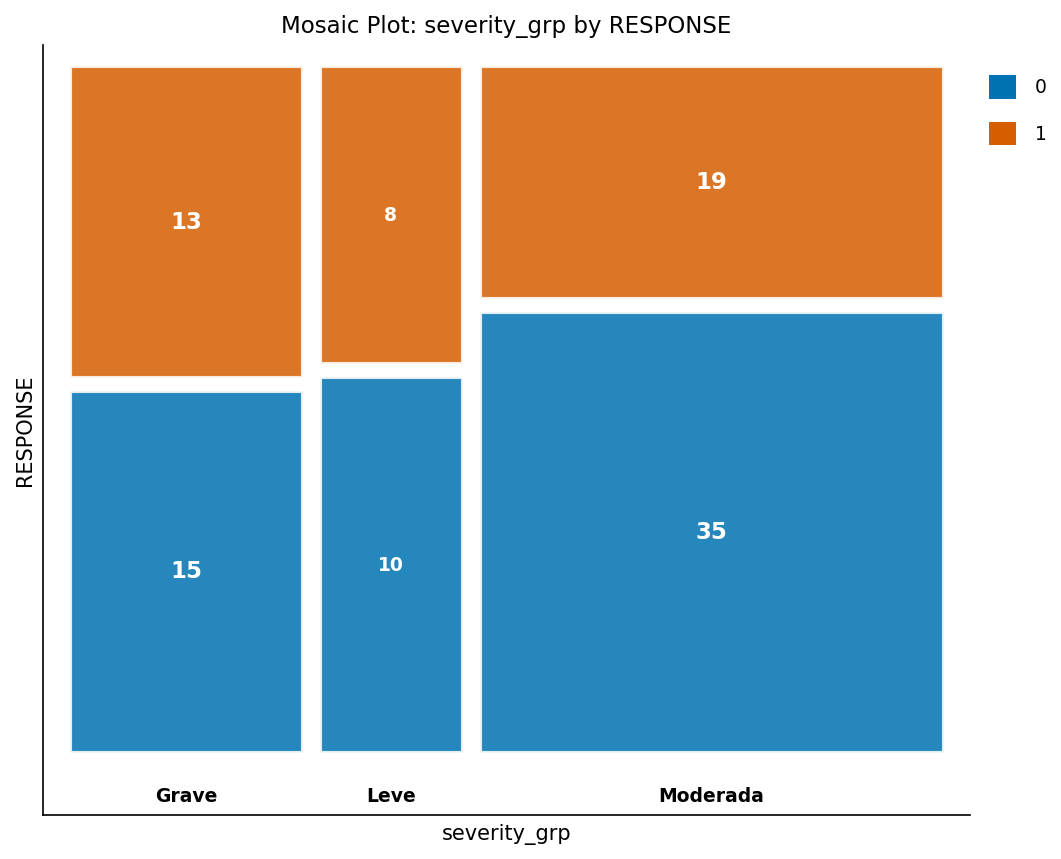

In [2]:
/* --------------------------------------------------------
   Recuentos de respuesta por grupo de tratamiento y
   estrato de gravedad, más resúmenes de covariables
   basales por grupo.
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.trial_resp;
    TABLES treatment_arm * RESPONSE / nocol nopercent;
    TABLES treatment_arm * severity_grp * RESPONSE / nocol nopercent;
    ETIQUETA treatment_arm="Grupo de tratamiento"
             RESPONSE="Respuesta"
             severity_grp="Estrato de gravedad basal";
    TÍTULO "Recuentos de respuesta por grupo y estrato de gravedad";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.trial_resp mean std MIN MAX;
    CLASE treatment_arm;
    VAR baseline_severity AGE;
    ETIQUETA treatment_arm="Grupo de tratamiento"
             baseline_severity="Gravedad basal (0-100)"
             AGE="Edad";
    TÍTULO "Resumen de covariables basales por grupo de tratamiento";
EJECUTAR;

---

                                Resumen de covariables basales por grupo de tratamiento                                 




NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


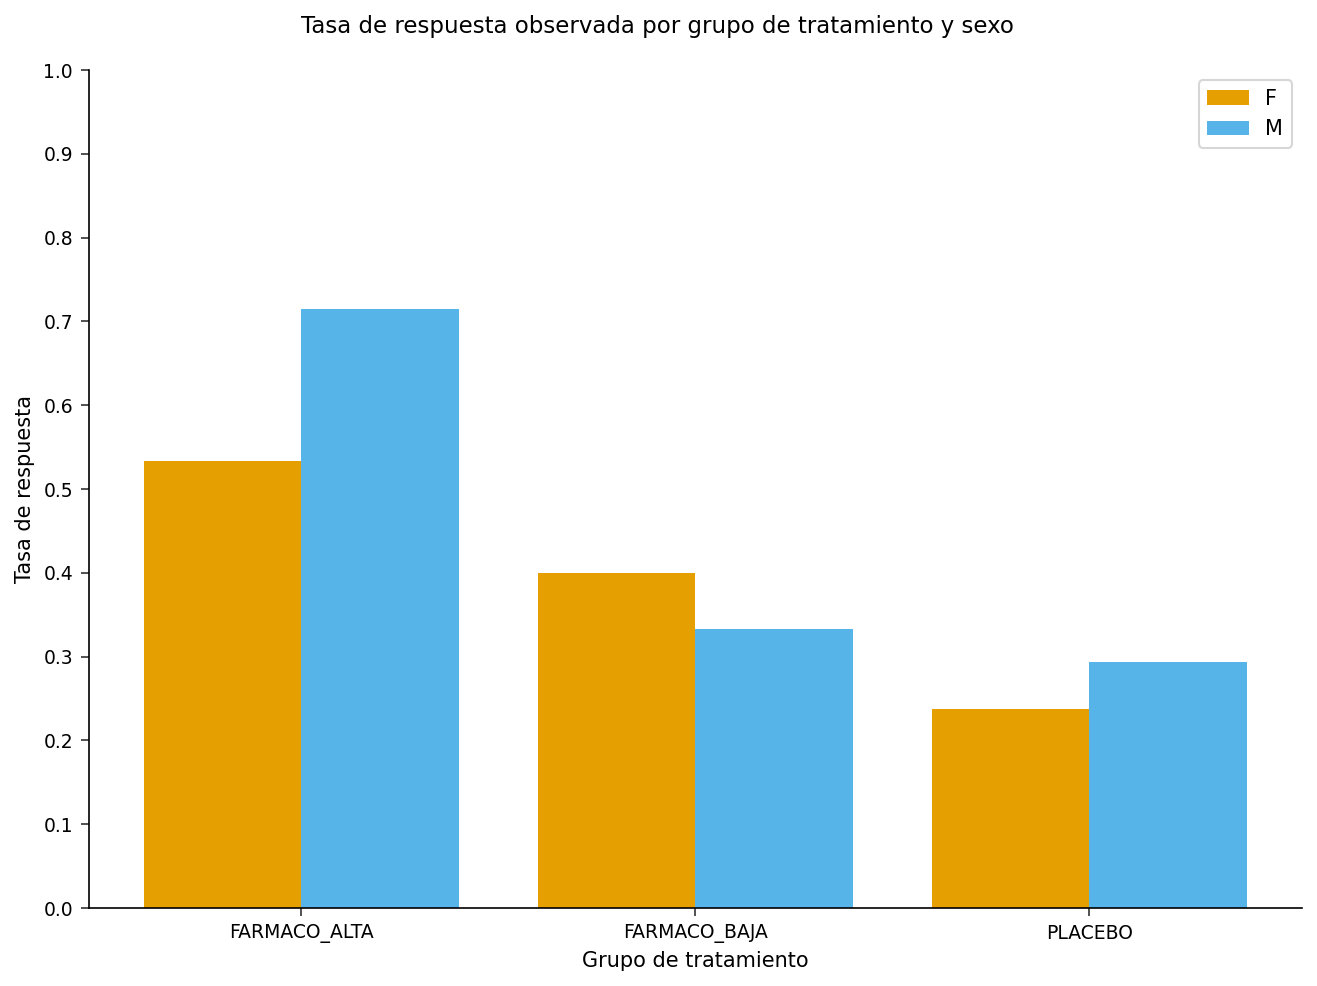

In [3]:
/* --------------------------------------------------------
   Tasa de respuesta por grupo de tratamiento y sexo
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.trial_resp;
    VBAR treatment_arm / RESPONSE=RESPONSE STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS ETIQUETA='Tasa de respuesta' VALUES=(0 HASTA 1 POR 0.1);
    XAXIS ETIQUETA='Grupo de tratamiento';
    TÍTULO 'Tasa de respuesta observada por grupo de tratamiento y sexo';
EJECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Modelo logit de máxima verosimilitud para la respuesta
   binaria. Ambos predictores son categóricos, por lo que
   CATMOD forma una pequeña tabla de contingencia (3 grupos
   x 3 estratos de gravedad = 9 poblaciones) y ajusta el
   logit de respuesta por máxima verosimilitud.
   RESPONSE LOGITS selecciona la función de respuesta logit.
   -------------------------------------------------------- */
PROCEDIMIENTO catmod DATOS=work.trial_resp;
    RESPONSE logits;
    MODELO RESPONSE = treatment_arm severity_grp
        / FRECUENCIAS prob pred=FRECUENCIAS;
    TÍTULO 'ANOVA logit: respuesta al tratamiento por grupo y estrato de gravedad basal';
EJECUTAR;

                                Resumen de covariables basales por grupo de tratamiento                                 


The CATMOD Procedure

Response: RESPONSE

Response Profiles
Response   RESPONSE            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          FARMACO_BAJA    Grave          
2          FARMACO_ALTA    Moderada       
3          PLACEBO         Leve           
4          PLACEBO         Grave          
5          PLACEBO         Moderada       
6          FARMACO_ALTA    Grave          
7          FARMACO_ALTA    Leve           
8          FARMACO_BAJA    Moderada       
9          FARMACO_BAJA    Leve           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660   


NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Capturar las estimaciones de parámetros con ODS OUTPUT
   para generar después el diagrama de bosque.
   -------------------------------------------------------- */
ODS SALIDA parameterestimates=work.catmod_parms;

PROCEDIMIENTO catmod DATOS=work.trial_resp;
    RESPONSE logits;
    MODELO RESPONSE = treatment_arm severity_grp;
EJECUTAR;

ODS SALIDA CLOSE;

                                Resumen de covariables basales por grupo de tratamiento                                 


The CATMOD Procedure

Response: RESPONSE

Response Profiles
Response   RESPONSE            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          FARMACO_BAJA    Grave          
2          FARMACO_ALTA    Moderada       
3          PLACEBO         Leve           
4          PLACEBO         Grave          
5          PLACEBO         Moderada       
6          FARMACO_ALTA    Grave          
7          FARMACO_ALTA    Leve           
8          FARMACO_BAJA    Moderada       
9          FARMACO_BAJA    Leve           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1          0.7660   


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Revisar las estimaciones de parámetros
   -------------------------------------------------------- */
PROCEDIMIENTO IMPRIMIR DATOS=work.catmod_parms;
    TÍTULO 'Estimaciones de parámetros CATMOD del modelo de respuesta al tratamiento';
EJECUTAR;

                        Estimaciones de parámetros CATMOD del modelo de respuesta al tratamiento                        

  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Interpretación

Todas las cifras de abajo se leen directamente de la salida ejecutada arriba.

**Tasas de respuesta observadas (PROC FREQ).** De los 5,000 pacientes, 1,841 (36.8%) fueron respondedores. La tasa de respuesta subió de forma constante con la dosis: PLACEBO 406/1,714 (23.7%), DRUG_LOW 607/1,637 (37.1%) y DRUG_HIGH 828/1,649 (50.2%). Colapsando entre brazos, la respuesta también aumentó con la severidad basal: Mild 405/1,220 (33.2%), Moderate 905/2,521 (35.9%) y Severe 531/1,259 (42.2%).

**Análisis de Varianza por Máxima Verosimilitud (PROC CATMOD).** CATMOD clasificó cruzadamente los datos en 9 poblaciones (3 brazos x 3 estratos de severidad) y ajustó el logit de respuesta por máxima verosimilitud. Ambos factores fueron altamente significativos: `treatment_arm` (chi-cuadrado = 245.67, gl = 2, p < 0.0001) y `severity_grp` (chi-cuadrado = 24.04, gl = 2, p < 0.0001). El estadístico de Razón de Verosimilitud residual (chi-cuadrado = 10.67, gl = 4, p = 0.0306) indica una falta de ajuste pequeña pero detectable respecto al modelo aditivo sin interacción, esperada aquí porque el proceso generador de datos permite que la pendiente de severidad difiera ligeramente por brazo.

**Estimaciones de parámetros (capturadas mediante ODS OUTPUT).** CATMOD utiliza codificación suma-cero (de efectos), y la función logit ajustada es el logaritmo de las probabilidades (log-odds) de *no respuesta* (respuesta = 0) relativa a respuesta = 1, de modo que una estimación negativa marca un nivel con respuesta superior a la media. El intercepto es 0.5520 (chi-cuadrado = 294.57), lo que refleja que los no respondedores superan en número a los respondedores en general. El efecto de DRUG_HIGH es -0.5738 (chi-cuadrado = 188.77, p < 0.0001) —fuertemente por debajo de la media general, es decir, el brazo con mejor respuesta— mientras que el efecto de DRUG_LOW es -0.0350 (p = 0.4098), cercano a la media general, con PLACEBO como la referencia positiva (peor respuesta). Para la severidad, el efecto de Severe es -0.2277 (chi-cuadrado = 23.68, p < 0.0001), confirmando una mayor respuesta en el estrato más severo, mientras que el efecto de Moderate (0.0553, p = 0.1702) no difiere significativamente de la media general.

**Conclusión.** El tratamiento activo y una mayor severidad basal elevan cada uno de forma independiente la probabilidad de respuesta clínica, siendo el brazo de dosis alta el que muestra el mayor efecto. Estas estimaciones de parámetros capturadas alimentan la exportación posterior del forest plot.

---

In [7]:
/* --------------------------------------------------------
   Exportar las estimaciones de parámetros para el
   diagrama de bosque.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>